# Laboratorio Interactivo: Algoritmos Genéticos (Metaheurísticas Poblacionales)

Bienvenidos a esta sesión avanzada de optimización evolutiva. A diferencia del Hill Climbing o el Simulated Annealing, que exploran el espacio de búsqueda mediante un único agente, los **Algoritmos Genéticos (AG)** emplean una *población* de agentes que interactúan, compiten y comparten información para navegar paisajes de energía complejos.

## 1. Definición del Problema: La Función de Ackley

El benchmark de Ackley es el némesis de los optimizadores locales. Combina un pozo global profundo con un ruido cosenoidal de alta frecuencia, creando miles de trampas locales.

**Fórmula matemática:**


$$f(x, y) = -20 \cdot \exp\left(-0.2 \sqrt{0.5(x^2 + y^2)}\right) - \exp\left(0.5(\cos(2\pi x) + \cos(2\pi y))\right) + 20 + e$$

* **Dominio:** $[-5, 5] \times [-5, 5]$
* **Óptimo global:** $\mathbf{x}^* = (0, 0)$ con $f(\mathbf{x}^*) = 0$.
* **Complejidad:** La topología exige un delicado balance entre la exploración (dispersión global) y la explotación (convergencia local).

---

### [Celda de Código 1: Librerías y Definición Matemática]

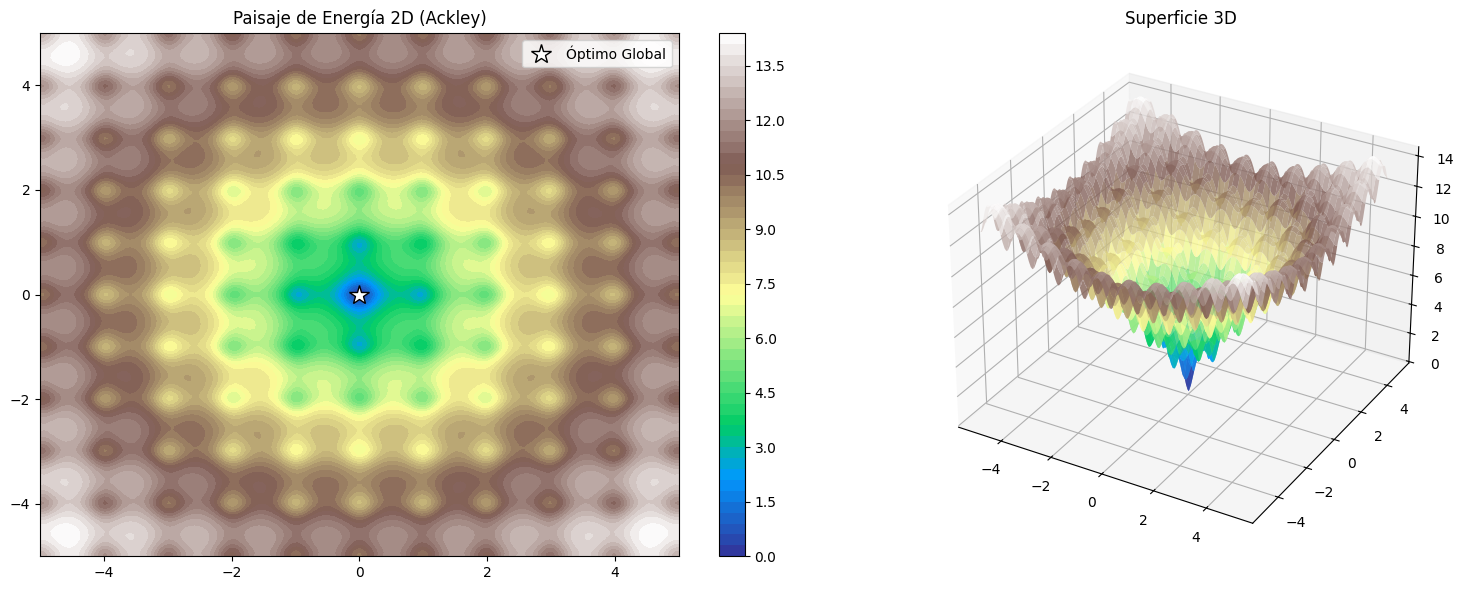

In [ ]:
# Importación de librerías para cálculo numérico y visualización interactiva
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# Configuración de matplotlib
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Límites del espacio de búsqueda
BOUNDS = np.array([[-5.0, 5.0], [-5.0, 5.0]])

def ackley(X, Y):
    """
    Función de Ackley 2D vectorizada.
    Evalúa la aptitud (fitness) de los individuos.
    """
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(0.5 * (X**2 + Y**2)))
    term2 = -np.exp(0.5 * (np.cos(2 * np.pi * X) + np.cos(2 * np.pi * Y)))
    return term1 + term2 + 20.0 + np.e

def plot_landscape():
    """Genera la visualización topológica 2D y 3D inicial."""
    x = np.linspace(BOUNDS[0][0], BOUNDS[0][1], 150)
    y = np.linspace(BOUNDS[1][0], BOUNDS[1][1], 150)
    X, Y = np.meshgrid(x, y)
    Z = ackley(X, Y)

    fig = plt.figure(figsize=(16, 6))

    # Contour 2D
    ax1 = fig.add_subplot(121)
    contour = ax1.contourf(X, Y, Z, levels=50, cmap='terrain')
    fig.colorbar(contour, ax=ax1)
    ax1.plot(0, 0, 'w*', markersize=15, markeredgecolor='k', label='Óptimo Global')
    ax1.set_title("Paisaje de Energía 2D (Ackley)")
    ax1.legend()

    # Surface 3D
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap='terrain', alpha=0.8, edgecolor='none')
    ax2.set_title("Superficie 3D")

    plt.tight_layout()
    plt.show()

plot_landscape()

---

### [Celda de Texto 2: Representación y Arquitectura del Algoritmo]

## 2. Arquitectura del Algoritmo Genético de Codificación Real

Al optimizar funciones continuas, no usamos cadenas de bits (0s y 1s). Usamos **Algoritmos Genéticos de Codificación Real**.

* **Individuo:** Un vector $\mathbf{v}_i = (x_i, y_i) \in \mathbb{R}^2$.
* **Fitness:** Como buscamos minimizar la función de Ackley, definimos la aptitud de manera que menores valores de la función sean más "aptos". En nuestra implementación lógica, ordenaremos la población ascendentemente por su valor en la función.
* **Selección (Torneo):** Escogemos $k$ individuos al azar y el de menor costo gana el derecho a reproducirse.
* **Cruce (Aritmético):** Dados los padres $\mathbf{p}_1$ y $\mathbf{p}_2$, un hijo se genera como una combinación convexa: $\mathbf{h} = \beta \mathbf{p}_1 + (1 - \beta) \mathbf{p}_2$, donde $\beta \sim U(0,1)$.
* **Mutación (Gaussiana):** Perturbamos genes aleatoriamente añadiendo ruido blanco: $x_{mutado} = x + \mathcal{N}(0, \sigma^2)$.

---

### [Celda de Código 2: Motor Lógico del Algoritmo Genético]

In [ ]:
class GeneticAlgorithmEngine:
    def __init__(self):
        self.bounds = BOUNDS
        self.reset()

    def reset(self, pop_size=50, p_cross=0.8, p_mut=0.1):
        self.pop_size = pop_size
        self.p_cross = p_cross
        self.p_mut = p_mut
        self.generation = 0

        # Inicialización uniforme en el dominio
        self.population = np.random.uniform(self.bounds[:, 0], self.bounds[:, 1], (self.pop_size, 2))
        self.fitness = self.evaluate_population(self.population)

        # Métricas de registro
        self.history_best_pos = []
        self.history_best_fit = []
        self.history_avg_fit = []
        self.history_diversity = []
        self.log = []

        self._update_metrics()

    def evaluate_population(self, pop):
        """Evalúa toda la matriz de la población."""
        return ackley(pop[:, 0], pop[:, 1])

    def _update_metrics(self):
        best_idx = np.argmin(self.fitness)
        self.history_best_pos.append(self.population[best_idx].copy())
        self.history_best_fit.append(self.fitness[best_idx])
        self.history_avg_fit.append(np.mean(self.fitness))
        # Diversidad: Promedio de la desviación estándar espacial de los individuos
        self.history_diversity.append(np.mean(np.std(self.population, axis=0)))

    def tournament_selection(self, k=3):
        """Selecciona al mejor individuo entre k escogidos al azar."""
        indices = np.random.choice(self.pop_size, k, replace=False)
        best_idx = indices[np.argmin(self.fitness[indices])]
        return self.population[best_idx]

    def step(self):
        """Ejecuta una única generación del Algoritmo Genético."""
        new_population = []
        self.log = [f"--- GENERACIÓN {self.generation + 1} ---"]

        # Elitismo: Guardar al mejor individuo intacto
        best_idx = np.argmin(self.fitness)
        elite = self.population[best_idx]
        new_population.append(elite)
        self.log.append(f"Elitismo: Individuo {np.round(elite, 2)} conservado (Fitness: {self.fitness[best_idx]:.4f}).")

        # Bucle reproductivo
        while len(new_population) < self.pop_size:
            # 1. Selección
            p1 = self.tournament_selection()
            p2 = self.tournament_selection()

            # 2. Cruce (Crossover Aritmético)
            if np.random.rand() < self.p_cross:
                beta = np.random.rand()
                child1 = beta * p1 + (1 - beta) * p2
                child2 = (1 - beta) * p1 + beta * p2
                if len(new_population) == 1: # Logguear solo un cruce de ejemplo
                    self.log.append(f"Cruce: Padres {np.round(p1,2)} y {np.round(p2,2)} -> Hijos {np.round(child1,2)}, {np.round(child2,2)}")
            else:
                child1, child2 = p1.copy(), p2.copy()

            # 3. Mutación (Ruido Gaussiano)
            if np.random.rand() < self.p_mut:
                child1 += np.random.normal(0, 0.5, 2)
            if np.random.rand() < self.p_mut:
                child2 += np.random.normal(0, 0.5, 2)

            # Restricción de límites (Clamping)
            child1 = np.clip(child1, self.bounds[:, 0], self.bounds[:, 1])
            child2 = np.clip(child2, self.bounds[:, 0], self.bounds[:, 1])

            new_population.append(child1)
            if len(new_population) < self.pop_size:
                new_population.append(child2)

        # 4. Reemplazo y Evaluación
        self.population = np.array(new_population)
        self.fitness = self.evaluate_population(self.population)
        self.generation += 1
        self._update_metrics()

---

### [Celda de Texto 3: Visualización Dinámica e Interactiva]

## 3. Dashboard Interactivo de Evolución Poblacional

El siguiente panel les permitirá manipular los hiperparámetros fundamentales de la evolución.

**Mecánica Visual:**

* **Mapa de Contornos:** Los puntos celestes representan a la población actual. La estrella negra indica al mejor individuo histórico.
* **Curvas de Convergencia:** Verán cómo el *Fitness Promedio* tiende a descender siguiendo al *Mejor Fitness*.
* **Curva de Diversidad:** Observen cómo la población "colapsa" geográficamente a medida que convergen hacia el óptimo.

---

### [Celda de Código 3: Panel GUI y Animación]

In [ ]:
def create_genetic_dashboard():
    engine = GeneticAlgorithmEngine()

    # Mallas estáticas para el plot
    X, Y = np.meshgrid(np.linspace(BOUNDS[0][0], BOUNDS[0][1], 100),
                       np.linspace(BOUNDS[1][0], BOUNDS[1][1], 100))
    Z = ackley(X, Y)

    # Controles Ipywidgets
    style = {'description_width': 'initial'}
    w_pop = widgets.IntSlider(value=50, min=10, max=200, step=10, description='Tamaño Población:', style=style)
    w_cross = widgets.FloatSlider(value=0.8, min=0.0, max=1.0, step=0.05, description='Prob. Cruce (Pc):', style=style)
    w_mut = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.05, description='Prob. Mutación (Pm):', style=style)
    w_gen = widgets.IntSlider(value=50, min=10, max=200, step=10, description='Generaciones a Simular:', style=style)

    btn_step = widgets.Button(description='Un Paso (Gen)', button_style='info')
    btn_run = widgets.Button(description='Animar Múltiples', button_style='success')
    btn_reset = widgets.Button(description='Reiniciar Población', button_style='danger')

    out_plot = widgets.Output()
    out_log = widgets.Output()

    def update_visuals():
        with out_plot:
            clear_output(wait=True)
            fig, axs = plt.subplots(1, 3, figsize=(18, 5))

            # 1. Población en el Espacio (Contour)
            ax_map = axs[0]
            ax_map.contourf(X, Y, Z, levels=40, cmap='terrain', alpha=0.6)
            ax_map.plot(0, 0, 'r*', markersize=15, label='Óptimo (0,0)')
            ax_map.scatter(engine.population[:, 0], engine.population[:, 1], c='cyan', edgecolors='k', alpha=0.7, label='Individuos')

            # Trayectoria del mejor individuo
            best_pos = np.array(engine.history_best_pos)
            ax_map.plot(best_pos[:, 0], best_pos[:, 1], 'k--', linewidth=1)
            ax_map.plot(best_pos[-1, 0], best_pos[-1, 1], 'k*', markersize=12, label='Mejor Actual')

            ax_map.set_title(f"Población en Generación {engine.generation}")
            ax_map.legend(loc='upper right')

            # 2. Curvas de Convergencia
            ax_conv = axs[1]
            gens = range(len(engine.history_best_fit))
            ax_conv.plot(gens, engine.history_best_fit, 'b-', linewidth=2, label='Mejor Fitness')
            ax_conv.plot(gens, engine.history_avg_fit, 'g--', alpha=0.7, label='Fitness Promedio')
            ax_conv.axhline(0, color='r', linestyle=':', label='Óptimo Teórico')
            ax_conv.set_title("Convergencia Evolutiva")
            ax_conv.set_xlabel("Generación")
            ax_conv.set_ylabel("Valor de Aptitud (Minimizar)")
            ax_conv.grid(True)
            ax_conv.legend()

            # 3. Evolución de la Diversidad
            ax_div = axs[2]
            ax_div.plot(gens, engine.history_diversity, 'm-', linewidth=2)
            ax_div.set_title("Diversidad Genética (Dispersión)")
            ax_div.set_xlabel("Generación")
            ax_div.set_ylabel("Desviación Estándar Espacial")
            ax_div.grid(True)

            plt.tight_layout()
            plt.show()

        with out_log:
            clear_output(wait=True)
            for line in engine.log:
                print(line)

    def on_reset(b):
        engine.reset(w_pop.value, w_cross.value, w_mut.value)
        update_visuals()

    def on_step(b):
        engine.step()
        update_visuals()

    def on_run(b):
        btn_run.disabled = True
        btn_step.disabled = True
        for _ in range(w_gen.value):
            engine.step()
            update_visuals()
            time.sleep(0.05) # Delay de animación
        btn_run.disabled = False
        btn_step.disabled = False

    # Enlaces de eventos
    btn_reset.on_click(on_reset)
    btn_step.on_click(on_step)
    btn_run.on_click(on_run)

    # Reaccionar si el usuario cambia el tamaño inicial poblacional
    w_pop.observe(lambda c: on_reset(None), 'value')

    controls = widgets.VBox([
        widgets.HBox([w_pop, w_cross, w_mut, w_gen]),
        widgets.HBox([btn_step, btn_run, btn_reset])
    ])

    display(controls, out_plot, out_log)
    on_reset(None)

create_genetic_dashboard()

Output()

Output()

---

### [Celda de Texto 4: Análisis Pedagógico y Comparación]

## 4. Análisis Crítico: Metaheurísticas en Perspectiva

A través del panel interactivo, ustedes han presenciado la dinámica poblacional del algoritmo. Ahora fundamentaremos el comportamiento empírico.

### Comparación con Métodos Anteriores:

1. **Hill Climbing (HC):** Representa una explotación local codiciosa. Falla en Ackley porque carece del mecanismo estocástico para cruzar los muros de energía de los óptimos locales. Es ciego al panorama general.
2. **Simulated Annealing (SA):** Mejora a HC al permitir escapes probabilísticos (gracias a la temperatura). Sin embargo, es una *trayectoria secuencial*. Si la temperatura cae muy rápido estando en un valle subóptimo, allí morirá.
3. **Algoritmos Genéticos (AG):** Efectúan un mapeo **paralelo e intrínseco** del espacio.
* **Exploración Global:** La inicialización distribuida y la mutación actúan como sondas geográficas dispersas.
* **Explotación Conjunta:** El cruce combina regiones de alto rendimiento (Ej. si un individuo halla una buena coordenada $X$, y otro una buena coordenada $Y$, el cruce puede ensamblar la solución perfecta).



### Errores Comunes de Parametrización (¡Pruébenlos en la simulación!):

* **Pérdida Prematura de Diversidad (Convergencia Prematura):** Ocurre si la Probabilidad de Mutación ($P_m$) es $0.0$. La población se "endogamia" y colapsa rápidamente hacia el óptimo local más cercano a la masa inicial. Observe cómo la gráfica de diversidad cae en picado a 0.
* **Ruido Destructivo (Pérdida de Explotación):** Si la Probabilidad de Mutación es altísima ($P_m \approx 0.8$), el algoritmo destruye la información evolutiva ganada. El comportamiento se degenera en una **Búsqueda Aleatoria Ciega** (Random Walk). La curva de convergencia será ruidosa y plana.
* **Población Insuficiente:** Usar $N=10$ para problemas altamente multidimensionales reduce drásticamente el "pool genético" inicial, forzando convergencias sesgadas.

---